# Multivariate Multifractals To Modelize Spatial Segregation

In [1]:
import pandas as pd
import numpy as np
rng = np.random.default_rng()
import matplotlib.pyplot as plt
import matplotlib as mpl
from skimage.measure import block_reduce

## Functions

In [2]:
def multivariate_lognormal_cascade(n, sigma1=1, sigma2=1, corr=0):
    mu1 = -1/2 * sigma1**2
    mu2 = -1/2 * sigma2**2

    PQ = np.exp(rng.multivariate_normal(np.array([mu1,mu2]),  np.array([[sigma1**2,corr*sigma1*sigma2], [corr*sigma1*sigma2, sigma2**2]]), 4))

    P = PQ[:,0].reshape(2,2)
    Q = PQ[:,1].reshape(2,2)
    for i in range(n):
        PQ = np.exp(rng.multivariate_normal(np.array([mu1,mu2]),np.array([[sigma1**2,corr*sigma1*sigma2], [corr*sigma1*sigma2, sigma2**2]]), P.shape[0]**2 * 4))
        P = np.kron(P, np.ones((2,2)))
        P = P * PQ[:,0].reshape(P.shape)
        Q = np.kron(Q, np.ones((2,2)))
        Q = Q * PQ[:,1].reshape(P.shape)

    P = P / np.sum(P)
    Q = Q / np.sum(Q)
    return(np.stack([P,Q], axis=-1))

def Theil(test):
  tp = test.sum(axis=2)
  prob = test[:,:,:] / tp[:,:, np.newaxis]
  ep = np.sum(-np.log2(prob) * prob, axis=2)
  e = (ep * tp / tp.sum()).sum()
  PROB =  test.sum(axis=(0,1)) / test.sum()
  E = -np.sum(PROB * np.log2(PROB))
  return(1 - (e/E))

### Estmation de la variance

In [57]:
rng = np.random.default_rng()
k=7
sigma1=.3
sigma2=.2
consts = [] 
sizes = 2**np.arange(8) 
corr=0.1
mus1s = []
for i in range(1000):
    lnc = multivariate_lognormal_cascade(k, sigma1=sigma1, sigma2=sigma2, corr=corr)
    lnc = block_reduce(lnc, block_size = (2,2,1), func = np.sum)
    mus1 = []
    const = []
    for i in sizes:
        temp = block_reduce(lnc, block_size = (i,i,1), func = np.sum)
        mus1.append(np.var(np.log(temp[:,:,0])))
        const.append(np.mean(np.log(temp[:,:,0])))
    mus1s.append(mus1)
    consts.append(const)

In [45]:
mus1s = np.array(mus1s).mean(axis=0)

In [46]:
sigma1**2/np.log(2), - np.sum((mus1s - np.mean(mus1s)) * (np.log(sizes) - np.log(sizes).mean())) / np.sum((np.log(sizes) - np.log(sizes).mean())**2)

(0.12984255368000672, 0.12958642889220887)

In [47]:
mus1s

array([0.6284844 , 0.54472003, 0.45628702, 0.36652992, 0.27650394,
       0.1856442 , 0.09597162, 0.        ])

In [48]:
sigma1**2/np.log(2) * np.log(sizes) #estimation de la variance de la loi lognorma et donc implicitement de la moyenne de la loi

array([0.  , 0.09, 0.18, 0.27, 0.36, 0.45, 0.54, 0.63])

In [50]:
sigma1**2 * np.log2(sizes)

array([0.  , 0.09, 0.18, 0.27, 0.36, 0.45, 0.54, 0.63])

In [58]:
consts = np.array(consts).mean(axis=0)

In [65]:
econst = 2 + sigma1**2/(2*np.log(2))

In [66]:
econst,  np.sum((consts - np.mean(consts)) * (np.log(sizes) - np.log(sizes).mean())) / np.sum((np.log(sizes) - np.log(sizes).mean())**2)

(2.0649212768400034, 2.064164413631206)

In [70]:
consts, econst * np.log(2) * np.log2(sizes) 

(array([-1.00139645e+01, -8.58580353e+00, -7.15537672e+00, -5.72430589e+00,
        -4.29304604e+00, -2.86146323e+00, -1.43102220e+00,  2.52020627e-16]),
 array([ 0.        ,  1.43129436,  2.86258872,  4.29388308,  5.72517744,
         7.15647181,  8.58776617, 10.01906053]))

In [73]:
np.log2(sizes) 

array([0., 1., 2., 3., 4., 5., 6., 7.])

### Test de l'estimation par DL de l'entropie de Finaza

In [74]:
def Theil(pop):
  tp = pop.sum(axis=2)
  prob = pop[:,:,:] / tp[:,:, np.newaxis]
  ep = np.sum(-np.log2(prob) * prob, axis=2)
  e = (ep * tp / tp.sum()).sum()
  return(1 - e)

Comparaison estimation et DL

In [117]:
rng = np.random.default_rng()

sigma1 = .15
sigma2 = .1
rho=.1

theils = []
for i in range(1000):
    lnc = multivariate_lognormal_cascade(k, sigma1=sigma1, sigma2=sigma2, corr=rho)
    lnc = block_reduce(lnc, block_size = (2,2,1), func = np.sum)
    theil = []
    for i in sizes:
        temp = block_reduce(lnc, block_size = (i,i,1), func = np.sum)
        theil.append(Theil(temp))
    theils.append(theil)
        
theils = np.mean(theils, axis=0)

In [118]:
theils

array([3.60570306e-02, 3.13052570e-02, 2.62682030e-02, 2.11498166e-02,
       1.59690720e-02, 1.07005423e-02, 5.43469350e-03, 6.21724894e-18])

In [119]:
econst1 = 2 + sigma1**2/(2*np.log(2))
alpha1s = -econst1 * np.log(2) * np.log2(sizes) 
econst2 = 2 + sigma2**2/(2*np.log(2))
alpha2s = -econst2 * np.log(2) * np.log2(sizes) 

mus1 = sigma1**2/np.log(2)
mus1s = mus1* np.log(sizes) 
mus2 = sigma2**2/np.log(2)
mus2s = mus2* np.log(sizes) 

In [122]:
theil_estimated = 1/(16*np.log(2)) *  sizes**2  * (np.exp(3*alpha1s - 2*alpha2s + 9/2*mus1s + 2 * mus2s - 6*rho*(mus1s * mus2s)**.5 ) 
                                                 -np.exp(2*alpha1s - alpha2s + 2*mus1s + 1/2*mus2s - 2*rho*(mus1s * mus2s)**.5 ))
theil_estimated

array([0.        , 0.00564408, 0.0119794 , 0.01907501, 0.02700645,
       0.03585643, 0.04571549, 0.05668268])

In [121]:
alpha1s

array([-0.        , -1.39754436, -2.79508872, -4.19263308, -5.59017744,
       -6.98772181, -8.38526617, -9.78281053])

In [75]:
rng = np.random.default_rng()
k=7
alpha1 = []
alpha2 = []
mus1 = []
mus2 = []
rho = []
theils = []
corr = .5
square = 1
sigma1 = .5
sigma2 = .05

for i in range(1000):
    lnc = multivariate_lognormal_cascade(k, sigma1=sigma1, sigma2=sigma2, corr=corr)
    lnc = block_reduce(lnc, block_size = (square,square,1), func = np.sum)
    size = lnc.shape[0]**2 
    alpha1.append(np.mean(np.log(lnc[:,:,0]).flatten()))
    alpha2.append(np.mean(np.log(lnc[:,:,1]).flatten()))
    mus1.append(np.var(np.log(lnc[:,:,0]).flatten()))
    mus2.append(np.var(np.log(lnc[:,:,1]).flatten()))
    rho.append(np.corrcoef(np.log(lnc[:,:,0]).flatten(), np.log(lnc[:,:,1]).flatten())[0,1])
    theils.append(theil(lnc))

#rho = corr
alpha1 = np.mean(alpha1)
alpha2 = np.mean(alpha2) 
mus1 = np.mean(mus1)
mus2 = np.mean(mus2)
rho = np.mean(rho)

theil_estimated = 1/(16*np.log(2)) * size  * (np.exp(3*alpha1 - 2*alpha2 + 9/2*mus1 + 2 * mus2 - 6*rho*(mus1 * mus2)**.5 ) 
                                             -np.exp(2*alpha1 - alpha2 + 2*mus1 + 1/2*mus2 - 2*rho*(mus1 * mus2)**.5 ))
                                             #-2*np.exp(2 * alpha1 + 2 * mus1))

print(np.mean(theils), theil_estimated, rho )


0.2561895893343657 16.718992849722323 0.5017474422087503


In [58]:
alpha1, 2  - sigma1**2/(2*np.log(2)) 

(-12.296050387976216, 1.4157085084399696)

In [91]:
mus1, 2 *sigma1**2/(np.log(2)) * 4

(1.9216324699591736, 2.8853900817779268)

In [77]:
1.6771992884066527 - 1.482408857022948, sigma1**2/(np.log(2))/2

(0.19479043138370478, 0.18033688011112042)

In [239]:
lnc = multivariate_lognormal_cascade(k, sigma1=.02, sigma2=.02, corr=.6)
lnc = block_reduce(lnc, block_size = (1,1,1), func = np.sum)

In [254]:
np.corrcoef(np.log(lnc[:,:,0]).flatten(), np.log(lnc[:,:,1]).flatten())[0,1]

0.478783133940208

In [233]:
np.log(lnc[:,:,1]).flatten()

array([-5.60503754, -5.55587674, -5.49936728, -5.54844236, -5.54760387,
       -5.50075265, -5.49561939, -5.53695347, -5.55767514, -5.5246317 ,
       -5.48931116, -5.47570274, -5.54371842, -5.57278834, -5.61640565,
       -5.62781082, -5.57652275, -5.56569303, -5.49112941, -5.55324746,
       -5.52792822, -5.55683511, -5.55722937, -5.52747021, -5.49110122,
       -5.57630324, -5.48581207, -5.50466994, -5.54453662, -5.55122486,
       -5.52615578, -5.57471625, -5.58468732, -5.54338103, -5.54574954,
       -5.53688135, -5.57279593, -5.54084103, -5.59052949, -5.53594365,
       -5.51918773, -5.53188181, -5.50061007, -5.57694759, -5.53733646,
       -5.55163436, -5.54832875, -5.58364681, -5.56847191, -5.58797057,
       -5.53661582, -5.5456788 , -5.62645834, -5.53980046, -5.58691021,
       -5.52195244, -5.53429533, -5.50324119, -5.53427895, -5.57088019,
       -5.55134464, -5.5405343 , -5.5758499 , -5.54986258, -5.59824199,
       -5.55977311, -5.57321748, -5.57064391, -5.61472985, -5.57

#### Test de la fonction multivariate_lognormal_cascade

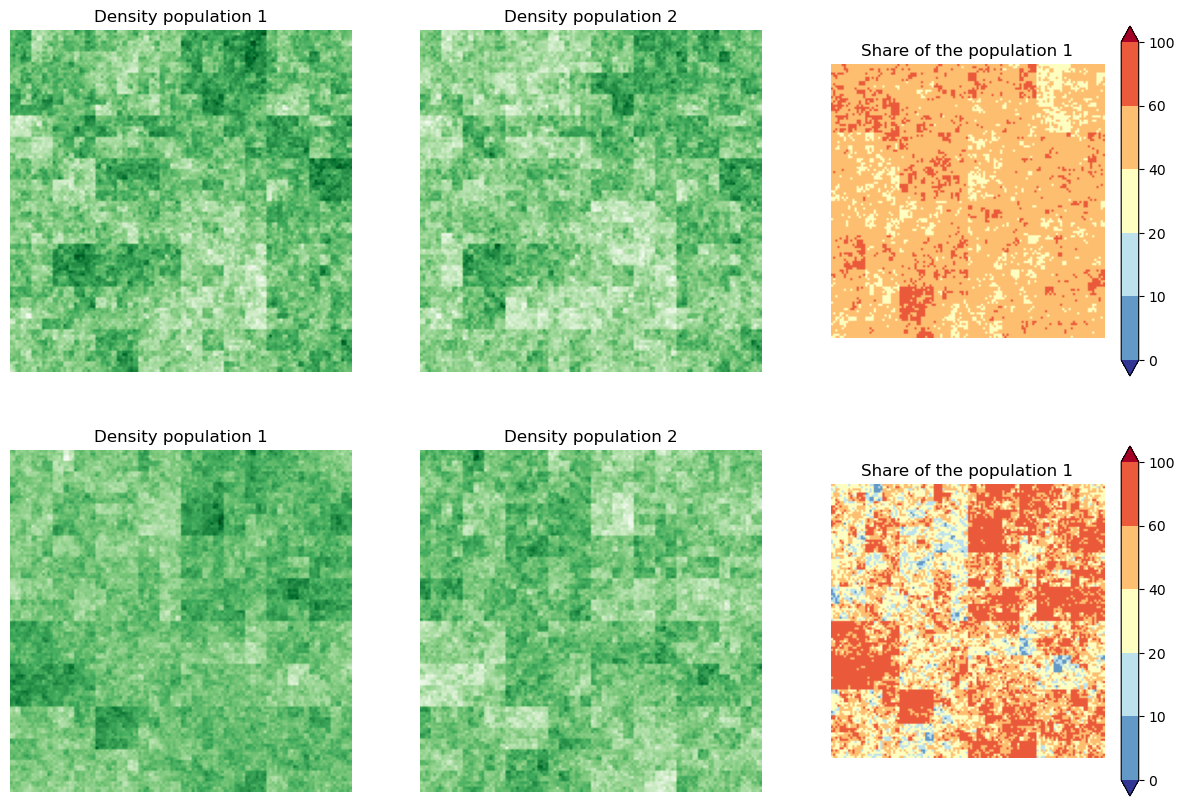

In [55]:
rng = np.random.default_rng(20021)
lnc = multivariate_lognormal_cascade(6, sigma1=.2, sigma2=.2, corr=.8)
ratio =   lnc[:,:,0] / (lnc[:,:,0] +  lnc[:,:,1]) * 100

cmap = mpl.cm.RdYlBu_r
bounds = [0, 10, 20, 40, 60, 100]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')
mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

fig, ax = plt.subplots(2, 3, figsize=(15, 10))

ax[0,0].set_axis_off();
ax[0,0].set_title('Density population 1');
ax[0,0].imshow(np.log(lnc[:,:,0]), cmap="Greens")

ax[0,1].set_axis_off();
ax[0,1].set_title('Density population 2');
ax[0,1].imshow(np.log(lnc[:,:,1]), cmap="Greens")

ax[0,2].set_axis_off();
ax[0,2].set_title('Share of the population 1');
ax[0,2].imshow(cmap(norm(ratio)))
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),ax=ax[0,2]);

rng = np.random.default_rng(269910)
lnc = multivariate_lognormal_cascade(6, sigma1=.2, sigma2=.2, corr=-.8)
ratio =   lnc[:,:,0] / (lnc[:,:,0] +  lnc[:,:,1]) * 100

ax[1,0].set_axis_off();
ax[1,0].set_title('Density population 1');
ax[1,0].imshow(np.log(lnc[:,:,0]), cmap="Greens")

ax[1,1].set_axis_off();
ax[1,1].set_title('Density population 2');
ax[1,1].imshow(np.log(lnc[:,:,1]), cmap="Greens")

ax[1,2].set_axis_off();
ax[1,2].set_title('Share of the population 1');
ax[1,2].imshow(cmap(norm(ratio)))
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),ax=ax[1,2]);


plt.savefig('comparaison_1.png')

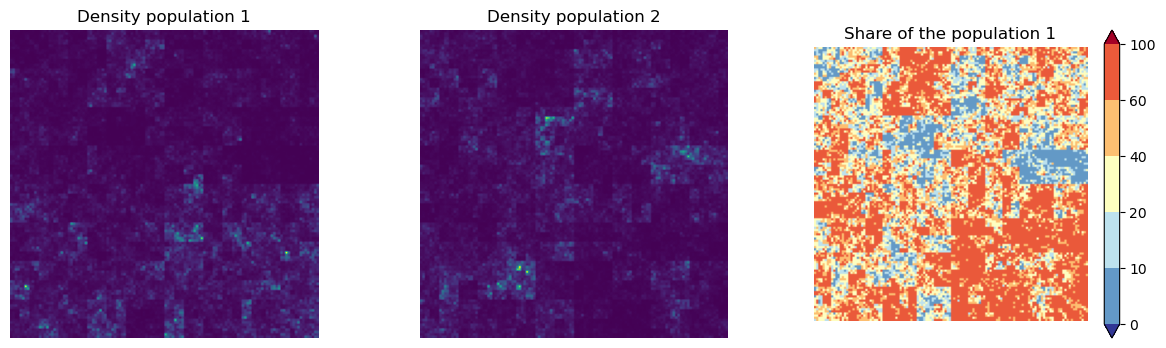

In [32]:
rng = np.random.default_rng(26102021)
lnc = multivariate_lognormal_cascade(6, sigma1=.4, sigma2=.4, corr=-.5)
ratio =   lnc[:,:,0] / (lnc[:,:,0] +  lnc[:,:,1]) * 100

cmap = mpl.cm.RdYlBu_r
bounds = [0, 10, 20, 40, 60, 100]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')
mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].set_axis_off();
ax[0].set_title('Density population 1');
ax[0].imshow(lnc[:,:,0])

ax[1].set_axis_off();
ax[1].set_title('Density population 2');
ax[1].imshow(lnc[:,:,1])

ax[2].set_axis_off();
ax[2].set_title('Share of the population 1');
ax[2].imshow(cmap(norm(ratio)))
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),ax=ax[2]);

### Calcul d'entropie

In [5]:
lnc = multivariate_lognormal_cascade(8, sigma1=.32, sigma2=.44, corr=-0.94)
pop = lnc[:,:,0]
pop = block_reduce(pop, block_size = (4,4), func = np.sum)

1.5499533899958564
1.338973220108091
1.130308865976589
0.8941435128693442


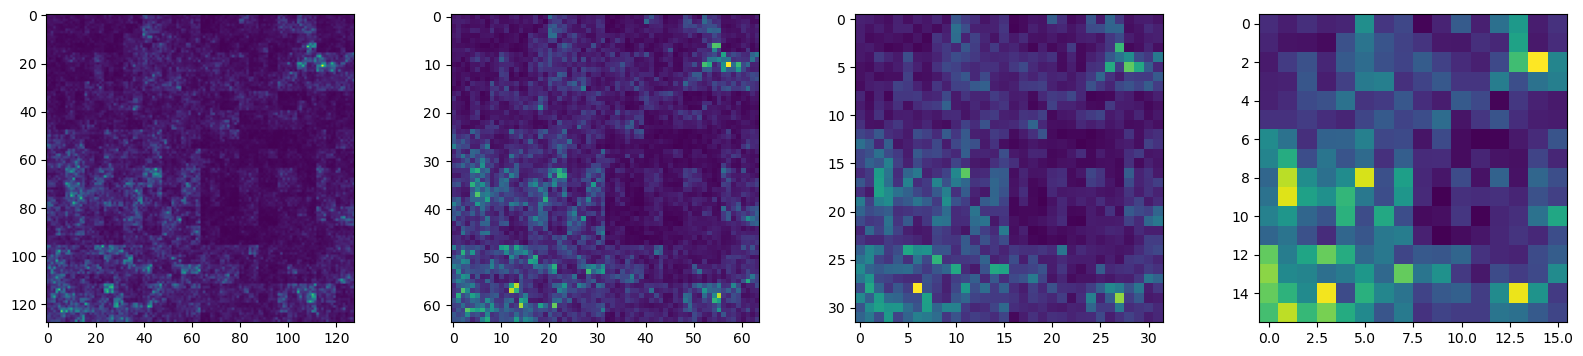

In [6]:
fig, axs = plt.subplots(1, 4, figsize=(20, 4))
for i in range(4):
  small_arr = block_reduce(pop, block_size=(2**i,2**i), func=np.sum)
  axs[i].imshow(small_arr)
  print(np.var(np.log2(small_arr.flatten())))

(array([  2.,   1.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,   2.,   6.,
          2.,   4.,   5.,   5.,   5.,   7.,   7.,  15.,  12.,  22.,  36.,
         28.,  34.,  48.,  48.,  61.,  85.,  85.,  85.,  96., 124., 131.,
        145., 154., 182., 202., 216., 201., 228., 284., 294., 323., 297.,
        330., 360., 372., 415., 435., 409., 445., 455., 492., 442., 486.,
        473., 454., 502., 529., 422., 435., 435., 439., 408., 386., 349.,
        341., 343., 294., 275., 261., 242., 211., 184., 191., 156., 135.,
        122., 107.,  88.,  81.,  67.,  57.,  47.,  49.,  38.,  20.,  31.,
         18.,  14.,  17.,  11.,   7.,  10.,   7.,   0.,   1.,   1.,   0.,
          1.]),
 array([-19.55179955, -19.46007255, -19.36834555, -19.27661855,
        -19.18489155, -19.09316455, -19.00143755, -18.90971055,
        -18.81798355, -18.72625655, -18.63452955, -18.54280255,
        -18.45107555, -18.35934855, -18.26762155, -18.17589454,
        -18.08416754, -17.99244054, -17.90071354, -17.80898654

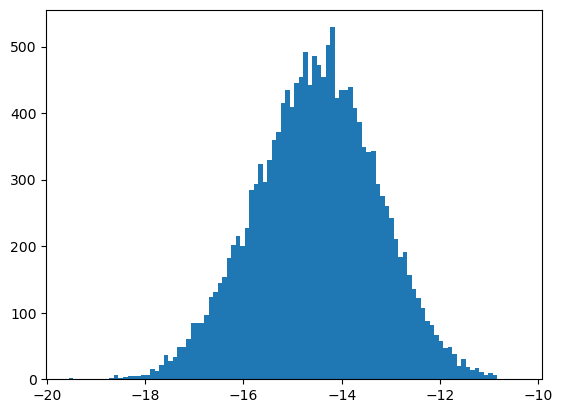

In [8]:
plt.hist(np.log2(pop.flatten('F')), bins=100)

### Valeur de alpha pour alpha = 0 et la variance de la parabole

---



In [8]:
sigma = 0.2
res = []
res2 = []
for i in range(10):
  lnc = multivariate_lognormal_cascade(10, sigma1=sigma, sigma2=.3, corr=.0)
  pop = block_reduce(lnc[:,:,0], block_size = (16,16), func = np.sum)
  entropies =  []
  entropies2 = []
  scales = np.array([i for i in range(1,4)])
  scales_exp2 = 2**scales
  for i in scales:
     small_arr = block_reduce(pop, block_size=(2**i,2**i), func=np.sum)
     entropies.append(-np.mean(np.log(small_arr)))
     entropies2.append(-np.var(np.log(small_arr)))
  entropies = np.array(entropies)
  entropies2 = np.array(entropies2)
  logscales = np.log(scales_exp2)
  res.append(-np.sum((entropies - entropies.mean()) * (logscales - logscales.mean())) / np.sum((logscales - logscales.mean())**2))
  res2.append(np.sum((entropies2 - entropies2.mean()) * (logscales - logscales.mean())) / np.sum((logscales - logscales.mean())**2))
np.mean(res), np.mean(res2)

(2.0293668282860917, 0.05851022956064814)

In [9]:
2 + (sigma**2) / 2 / np.log(2)  , sigma**2   / np.log(2)

(2.0288539008177793, 0.057707801635558546)

### Valeur de f(alpha) = alpha pour alpha = 1

In [ ]:
sigma = 0.25

In [ ]:
res = []
for i in range(10):
  lnc = multivariate_lognormal_cascade(10, sigma1=sigma, sigma2=.4, corr=.0)
  pop = block_reduce(lnc[:,:,0], block_size = (16,16), func = np.sum)
  entropies =  []
  scales = np.array([i for i in range(1,4)])
  for i in scales:
     small_arr = block_reduce(pop, block_size=(2**i,2**i), func=np.sum)
     entropies.append(-np.sum(small_arr * np.log2(small_arr)))
  entropies = np.array(entropies)
  res.append(-np.sum((entropies - entropies.mean()) * (scales - scales.mean())) / np.sum((scales - scales.mean())**2))
np.mean(res)

np.float64(1.9535754387415245)

In [ ]:

mu = -1/2 * sigma**2 - np.log(4)

res = []
for i in range(10000000):
  samples = np.exp(np.random.normal(mu, sigma, size=4))
  #samples = samples / samples.sum()
  res.append(-np.sum(samples * np.log2(samples)))

print(np.mean(res))

1.9549133349221879


Vraie Valeur

In [ ]:
2 - ((sigma**2)/2 / np.log(2))

np.float64(1.9549157799722199)

### Calcul de la divergence

In [ ]:
sigma2

0.5744562646538028

In [ ]:
sigma1 = 0.178**0.5
sigma2 = 0.309**0.5
rho = -.185

In [ ]:
res = []
for i in range(10):
  lnc = multivariate_lognormal_cascade(10, sigma1=sigma1, sigma2=sigma2, corr=rho)
  pop1 = block_reduce(lnc[:,:,0], block_size = (16,16), func = np.sum)
  pop2 = block_reduce(lnc[:,:,1], block_size = (16,16), func = np.sum)
  entropies =  []
  scales = np.array([i for i in range(4)])
  for i in scales:
    small_arr1 = block_reduce(pop1, block_size=(2**i,2**i), func=np.sum)
    small_arr2 = block_reduce(pop2, block_size=(2**i,2**i), func=np.sum)
    entropies.append(np.sum(small_arr1 * np.log2(small_arr1/small_arr2)))
  entropies = np.array(entropies)
  res.append(-np.sum((entropies - entropies.mean()) * (scales - scales.mean())) / np.sum((scales - scales.mean())**2))
print(np.mean(res), + (sigma1**2+sigma2**2 - 2*rho*sigma1*sigma2) / np.log(2 ) / 2)

0.41490091734154155 0.4138906464022402


In [ ]:
(sigma1**2+sigma2**2 - 2*rho*sigma1*sigma2) / np.log(2 ) / 2

np.float64(0.4138906464022402)

### Application Paris

In [9]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [12]:
paris = np.load('paris_household.npy')

In [13]:
pop1 = paris[:,:,0]
pop2 = paris[:,:,1]
#pop2[(pop2<1) & (pop1>0)] = 1
pop1 = pop1 / pop1.sum()
pop2 = pop2 / pop2.sum()

In [14]:
entropies1_1 =  []
entropies1_2 = []

entropies2_1 =  []
entropies2_2 = []

entropies_rho = []


scales = np.array([i for i in range(1,4)])
scales_exp2 = 2**scales
for i in scales:
  small_arr1 = block_reduce(pop1, block_size=(2**i,2**i), func=np.sum)
  small_arr2 = block_reduce(pop2, block_size=(2**i,2**i), func=np.sum)
  entropies1_1.append(-np.mean(np.log(small_arr1[small_arr1>0])))
  entropies1_2.append(-np.var(np.log(small_arr1[small_arr1>0])))
  entropies2_1.append(-np.mean(np.log(small_arr2[small_arr2>0])))
  entropies2_2.append(-np.var(np.log(small_arr2[small_arr2>0])))
  entropies_rho.append(np.sum(small_arr1[small_arr1>0] * np.log2(small_arr1[small_arr1>0]/small_arr2[small_arr1>0])))
entropies1_1 = np.array(entropies1_1)
entropies1_2 = np.array(entropies1_2)
entropies2_1 = np.array(entropies2_1)
entropies2_2 = np.array(entropies2_2)
entropies_rho = np.array(entropies_rho)

logscales = np.log(scales_exp2)


print(-np.sum((entropies1_1 - entropies1_1.mean()) * (logscales - logscales.mean())) / np.sum((logscales - logscales.mean())**2))
print(np.sum((entropies1_2 - entropies1_2.mean()) * (logscales - logscales.mean())) / np.sum((logscales - logscales.mean())**2) * np.log(2))

print(-np.sum((entropies2_1 - entropies1_1.mean()) * (logscales - logscales.mean())) / np.sum((logscales - logscales.mean())**2))
print(np.sum((entropies2_2 - entropies1_2.mean()) * (logscales - logscales.mean())) / np.sum((logscales - logscales.mean())**2) * np.log(2))

print(-np.sum((entropies_rho - entropies_rho.mean()) * (scales - scales.mean())) / np.sum((scales - scales.mean())**2))

2.0882061202117903
0.6225466617723552
2.136759237637476
0.9107423532096949
0.04132066218092284


In [15]:
entropies_rho

array([0.24593577, 0.201571  , 0.16329445])

In [ ]:
-(((0.414 * 2 * np.log(2)) - (0.178 + 0.309)) / (0.178 * 0.309)**0.5 / 2)

np.float64(-0.18532319846999554)

In [ ]:
entropies_rho

array([-625568.88914231, -645574.68502432, -658356.60649728,
       -669384.45016474])

In [ ]:
res = []
for i in range(1000000):
  samples = np.exp(np.random.normal(mu, sigma, size=4))
  res.append(samples.sum())
np.mean(res)

np.float64(0.9999320967820047)

In [ ]:
np.sum((entropies - entropies.mean()) * (scales - scales.mean())) / np.sum((scales - scales.mean())**2)

np.float64(-1.4638276075246432)

### Analyse de theil des cascades multifractales

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
paris = np.load('drive/MyDrive/segregation/data/paris_household.npy')

In [16]:
ptot = paris[:,:,0].sum() + paris[:,:,1].sum()
p0 = paris[:,:,0].sum() / ptot.sum(),
p1 = paris[:,:,1].sum() / ptot.sum()

In [17]:
lnc = multivariate_lognormal_cascade(, sigma1=0.178**0.5, sigma2=0.309**0.5, corr=-.185)

In [20]:
test = lnc.copy( )

In [ ]:
res = []
for i in range(10000):
  lnc = multivariate_lognormal_cascade(6, sigma1=0.2**0.5, sigma2=0.2**0.5, corr=.2)
  test = lnc.copy( )
  test[:,:,0] = test[:,:,0] * p0 * 100
  test[:,:,1] = test[:,:,1] * p1 * 100
  res.append(Theil(test))
plt.hist(res, bins='auto');

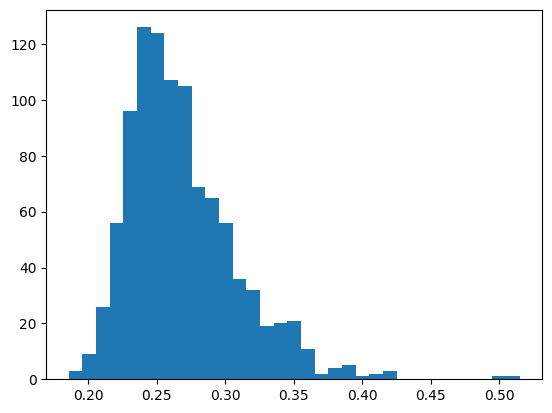

In [ ]:
res = []
for i in range(1000):
  lnc = multivariate_lognormal_cascade(6, sigma1=0.1**0.5, sigma2=0.8**0.5, corr=1)
  test = lnc.copy( )
  test[:,:,0] = test[:,:,0] * p0 * 100
  test[:,:,1] = test[:,:,1] * p1 * 100
  res.append(Theil(test))
plt.hist(res, bins='auto');

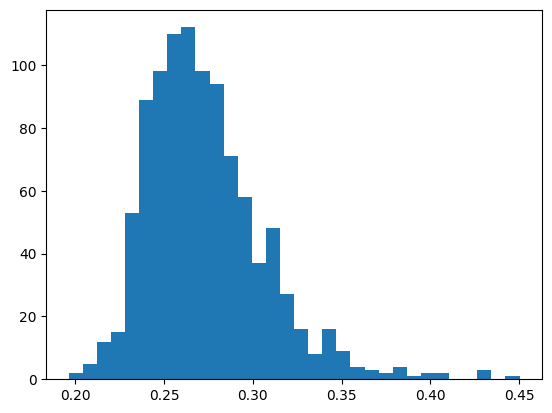

In [ ]:
plt.hist(res, bins='auto');

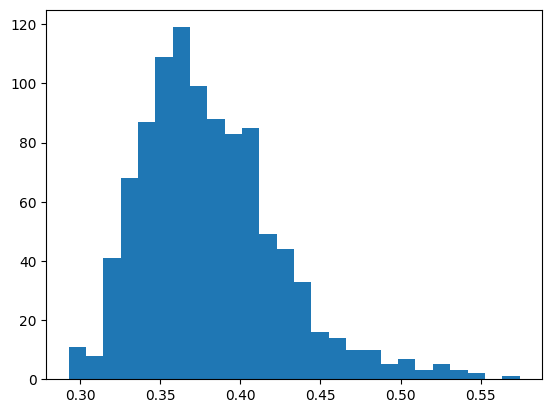

In [30]:
res = []
for i in range(1000):
  lnc = multivariate_lognormal_cascade(6, sigma1=0.2**0.5, sigma2=0.2**0.5, corr=-.2)
  test = lnc.copy( )
  test[:,:,0] = test[:,:,0] * p0 * 100
  test[:,:,1] = test[:,:,1] * p1 * 100
  res.append(Theil(test))
plt.hist(res, bins='auto');

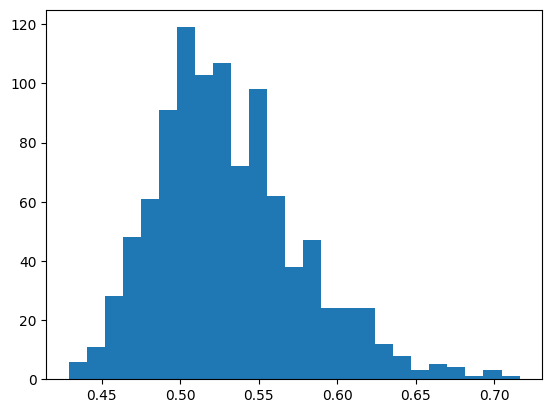

In [ ]:
res = []
for i in range(1000):
  lnc = multivariate_lognormal_cascade(6, sigma1=0.2**0.5, sigma2=0.2**0.5, corr=-.9)
  test = lnc.copy( )
  test[:,:,0] = test[:,:,0] * p0 * 100
  test[:,:,1] = test[:,:,1] * p1 * 100
  res.append(Theil(test))
plt.hist(res, bins='auto');

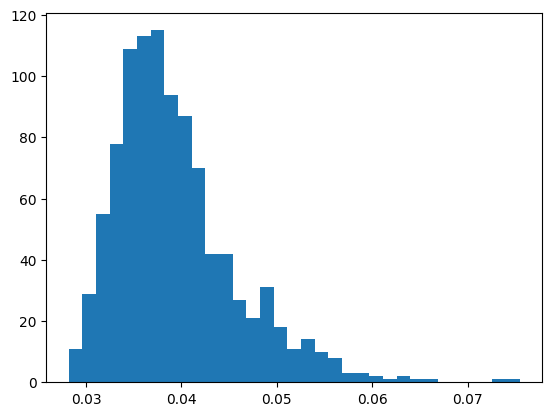

In [ ]:
res = []
for i in range(1000):
  lnc = multivariate_lognormal_cascade(6, sigma1=0.2**0.5, sigma2=0.2**0.5, corr=.9)
  test = lnc.copy( )
  test[:,:,0] = test[:,:,0] * p0 * 100
  test[:,:,1] = test[:,:,1] * p1 * 100
  res.append(Theil(test))
plt.hist(res, bins='auto');

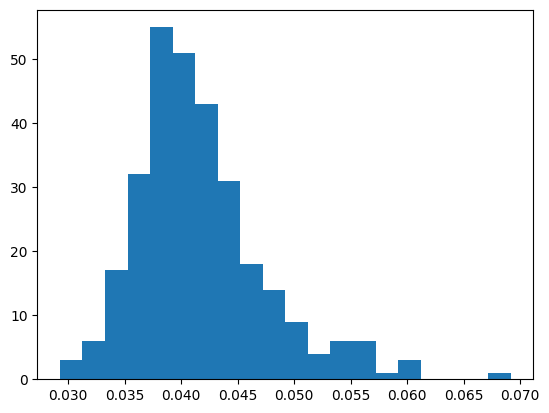

In [ ]:
res = []
for i in range(300):
  lnc = multivariate_lognormal_cascade(10, sigma1=0.2**0.5, sigma2=0.2**0.5, corr=.9)
  lnc = block_reduce(lnc, block_size = (16,16,1), func = np.sum)

  test = lnc.copy( )
  test[:,:,0] = test[:,:,0] * p0 * 100
  test[:,:,1] = test[:,:,1] * p1 * 100
  res.append(Theil(test))
plt.hist(res, bins='auto');

In [ ]:
lnc = multivariate_lognormal_cascade(10, sigma1=0.2**0.5, sigma2=0.2**0.5, corr=.9)
block_reduce(lnc, block_size = (16,16,1), func = np.sum).shape

(128, 128, 2)

### Theil multi échelle

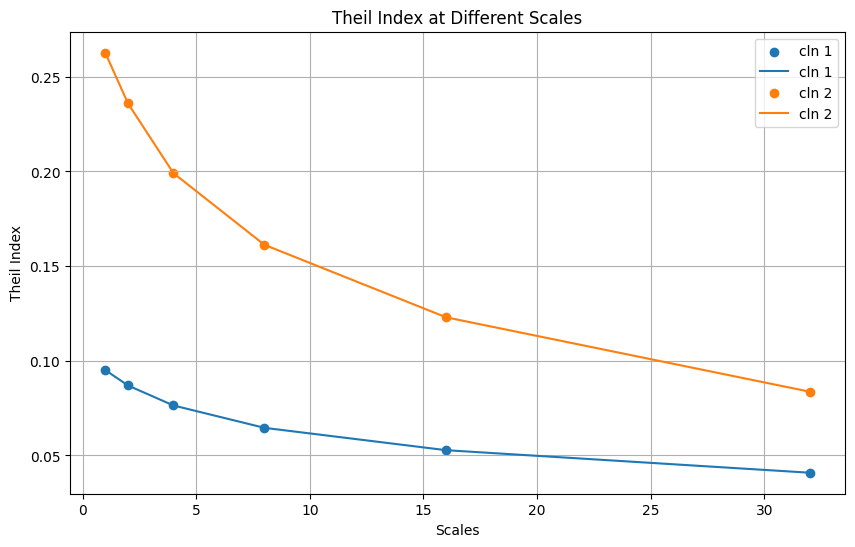

In [118]:
lnc = multivariate_lognormal_cascade(6, sigma1=0.1**0.5, sigma2=0.1**0.5, corr=.6)
test1 = lnc.copy( )
test1[:,:,0] = test1[:,:,0] * p0
test1[:,:,1] = test1[:,:,1] * p1

lnc = multivariate_lognormal_cascade(6, sigma1=0.1**0.5, sigma2=0.1**0.5, corr=-.6)
test2 = lnc.copy( )
test2[:,:,0] = test2[:,:,0] * p0
test2[:,:,1] = test2[:,:,1] * p1

scales = 2**np.array([i for i in range(0,6)])
theils1 = []
theils2 = []
for s in scales:
  small_arr1 = block_reduce(test1, block_size=(s,s,1), func=np.sum)
  theils1.append(Theil(small_arr1))
  small_arr2 = block_reduce(test2, block_size=(s,s,1), func=np.sum)
  theils2.append(Theil(small_arr2))

plt.figure(figsize=(10, 6))
#plt.xscale('log')
plt.scatter(scales, theils1, label='cln 1')
plt.plot(scales, theils1, label='cln 1')
plt.scatter(scales, theils2, label='cln 2')
plt.plot(scales, theils2, label='cln 2')

plt.xlabel('Scales')
plt.ylabel('Theil Index')
plt.title('Theil Index at Different Scales')
plt.legend()
plt.grid(True)
plt.show()

In [56]:
scales = 2**np.array([i for i in range(0,7)])
theils1 = []
theils2 = []
for s in scales:
  small_arr1 = block_reduce(test1, block_size=(s,s,1), func=np.sum)
  theils1.append(Theil(small_arr1))
  small_arr2 = block_reduce(test2, block_size=(s,s,1), func=np.sum)
  theils2.append(Theil(small_arr2))


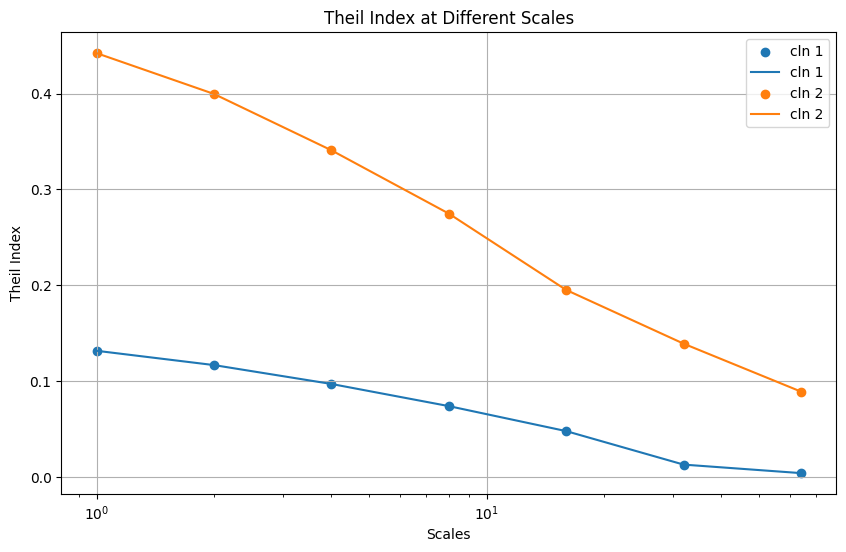

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
#plt.xscale('log')
#plt.yscale('log')

plt.scatter(scales, theils1, label='cln 1')
plt.plot(scales, theils1, label='cln 1')
plt.scatter(scales, theils2, label='cln 2')
plt.plot(scales, theils2, label='cln 2')

plt.xlabel('Scales')
plt.ylabel('Theil Index')
plt.title('Theil Index at Different Scales')
plt.legend()
plt.grid(True)
plt.show()

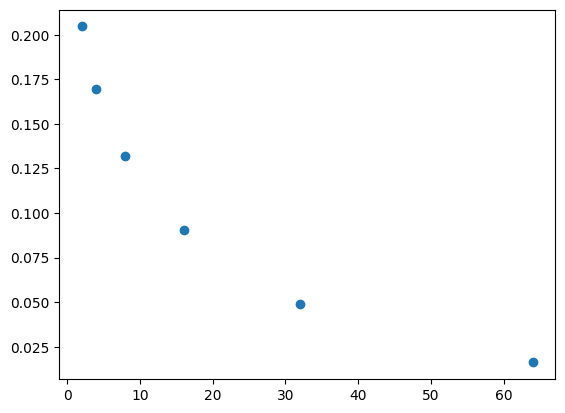

In [ ]:
plt.scatter(scales,theils)

In [ ]:
t[:,:, np.newaxis]

array([[[9.78791047e-06],
        [1.50176399e-05],
        [1.26316326e-05],
        ...,
        [1.35549318e-05],
        [1.72112279e-05],
        [1.71400439e-05]],

       [[1.32123208e-05],
        [8.95336681e-06],
        [4.73459140e-06],
        ...,
        [1.36039405e-05],
        [8.09529332e-06],
        [1.24594840e-05]],

       [[1.40536476e-05],
        [1.87568486e-05],
        [1.66056685e-05],
        ...,
        [1.26232337e-05],
        [1.04575850e-05],
        [1.49851063e-05]],

       ...,

       [[1.22595550e-05],
        [1.52965682e-05],
        [7.93673193e-06],
        ...,
        [3.03585561e-05],
        [4.71359978e-05],
        [3.31009820e-05]],

       [[1.08283162e-05],
        [1.03888571e-05],
        [2.82405486e-06],
        ...,
        [1.80673475e-05],
        [4.64667604e-05],
        [5.81465651e-05]],

       [[1.01762358e-05],
        [1.31523199e-05],
        [6.73553901e-06],
        ...,
        [2.46560192e-05],
        [6.8999

## Duncan Segregation Index

In [28]:
def Duncan(pop_array):
  prob_array = pop_array / pop_array.sum(axis=(0,1))
  return(1/2 * np.abs(prob_array[:,:,0] - prob_array[:,:,1]).sum())

In [29]:
Duncan(paris)

np.float64(0.2517930664245248)

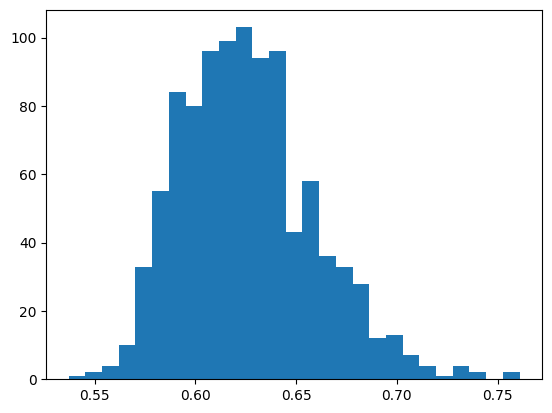

In [32]:
res = []
for i in range(1000):
  lnc = multivariate_lognormal_cascade(6, sigma1=0.2**0.5, sigma2=0.2**0.5, corr=-.2)
  res.append(Duncan(lnc))
plt.hist(res, bins='auto');

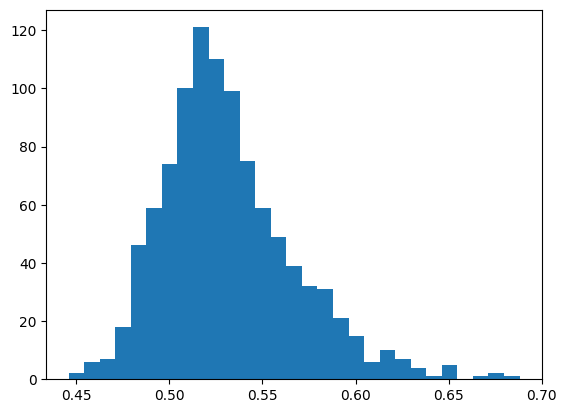

In [35]:
res = []
for i in range(1000):
  lnc = multivariate_lognormal_cascade(6, sigma1=0.2**0.5, sigma2=0.2**0.5, corr=.2)
  res.append(Duncan(lnc))
plt.hist(res, bins='auto');

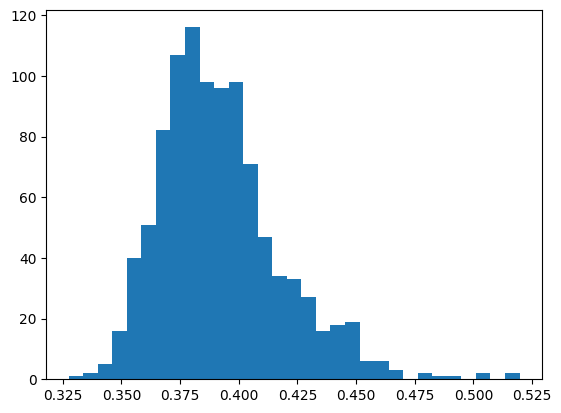

In [36]:
res = []
for i in range(1000):
  lnc = multivariate_lognormal_cascade(6, sigma1=0.1**0.5, sigma2=0.1**0.5, corr=.2)
  res.append(Duncan(lnc))
plt.hist(res, bins='auto');

Multiechelle

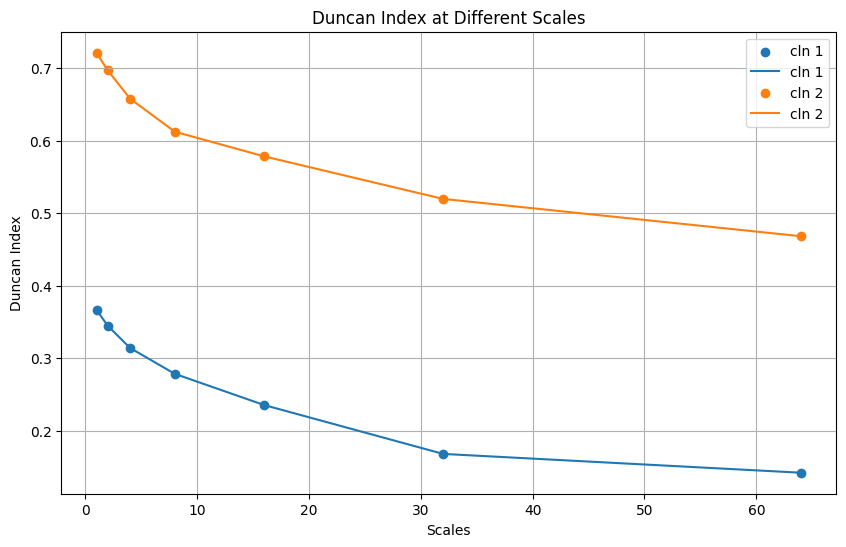

In [80]:
test1 = multivariate_lognormal_cascade(6, sigma1=0.2**0.5, sigma2=0.2**0.5, corr=.6)
test2 = multivariate_lognormal_cascade(6, sigma1=0.2**0.5, sigma2=0.2**0.5, corr=-.6)

scales = 2**np.array([i for i in range(0,7)])
Duncans1 = []
Duncans2 = []
for s in scales:
  small_arr1 = block_reduce(test1, block_size=(s,s,1), func=np.sum)
  Duncans1.append(Duncan(small_arr1))
  small_arr2 = block_reduce(test2, block_size=(s,s,1), func=np.sum)
  Duncans2.append(Duncan(small_arr2))

plt.figure(figsize=(10, 6))
plt.scatter(scales, Duncans1, label='cln 1')
plt.plot(scales, Duncans1, label='cln 1')
plt.scatter(scales, Duncans2, label='cln 2')
plt.plot(scales, Duncans2, label='cln 2')

plt.xlabel('Scales')
plt.ylabel('Duncan Index')
plt.title('Duncan Index at Different Scales')
plt.legend()
plt.grid(True)
plt.show()

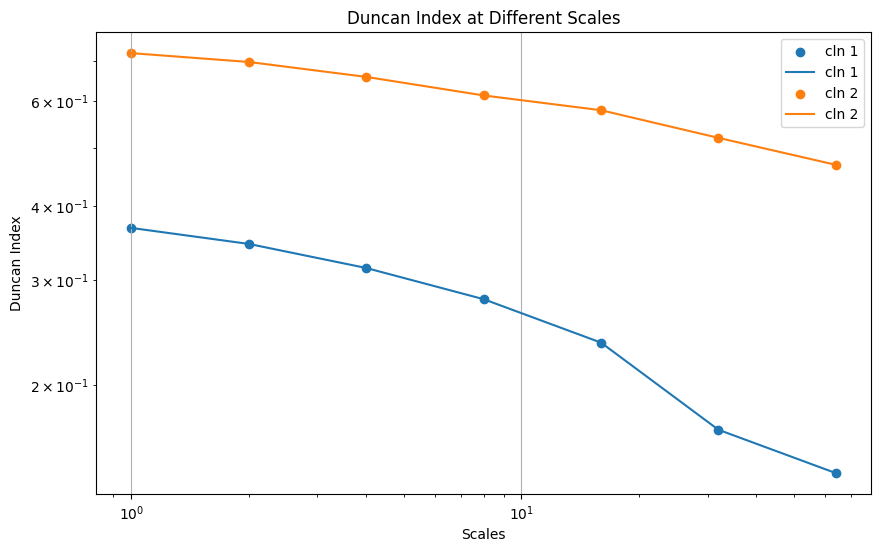

In [87]:
plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.yscale('log')

plt.scatter(scales, Duncans1, label='cln 1')

plt.plot(scales, Duncans1, label='cln 1')
plt.scatter(scales, Duncans2, label='cln 2')
plt.plot(scales, Duncans2, label='cln 2')

plt.xlabel('Scales')
plt.ylabel('Duncan Index')
plt.title('Duncan Index at Different Scales')
plt.legend()
plt.grid(True)
plt.show()

